In [29]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [30]:
x,y = make_blobs(n_samples=1000, centers=3, n_features=2, )

In [31]:
x

array([[ 5.4933187 , -4.45481734],
       [ 6.49561263, -4.69926479],
       [ 5.41531445,  3.27367473],
       ...,
       [ 4.27329233, -3.44706458],
       [ 7.1274562 , -3.09734377],
       [ 6.85500853, -4.42093872]], shape=(1000, 2))

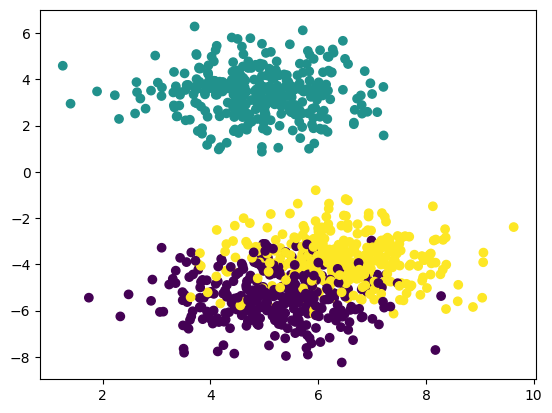

In [32]:
plt.scatter(x[:,0], x[:,1], c=y)

In [34]:
## standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_x = scaler.fit_transform(x)


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_x, y, test_size=0.3, random_state=42)

In [36]:
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [37]:
from sklearn.cluster import KMeans


In [38]:
## elbow method to find the optimal number of clusters
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [39]:
wcss

[1400.0,
 677.5136238366392,
 378.942335888583,
 293.72823768611875,
 202.91789810522755,
 171.536465803848,
 142.78555447515058,
 125.89584512454762,
 111.66355291594802,
 112.52952928728126]

Text(0, 0.5, 'WCSS')

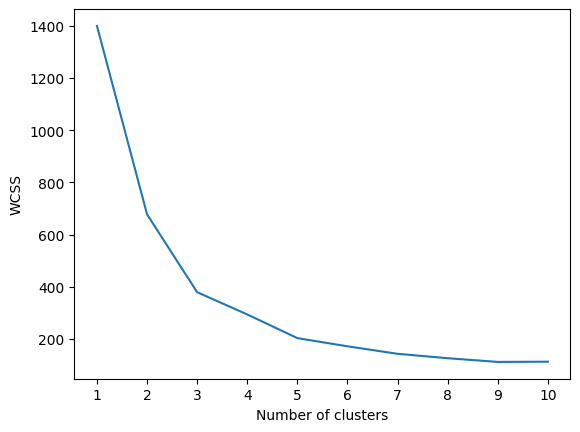

In [40]:
## plot the elbow curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')


In [41]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [42]:
kmeans.fit_predict(x_train)

array([2, 0, 1, 1, 2, 0, 2, 0, 1, 0, 2, 2, 1, 2, 1, 2, 0, 2, 2, 2, 2, 0,
       0, 2, 2, 1, 2, 1, 1, 1, 0, 0, 1, 2, 0, 2, 2, 1, 1, 2, 2, 1, 0, 2,
       2, 2, 2, 2, 0, 1, 0, 0, 0, 0, 1, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 0, 2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 1, 2, 1,
       0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0, 2, 1, 2, 2, 1, 0,
       0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 0, 1, 1, 0, 2, 2, 0, 1, 2, 2, 0, 0,
       0, 2, 1, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 1,
       1, 0, 2, 0, 0, 1, 0, 1, 0, 1, 2, 0, 2, 2, 2, 1, 1, 1, 1, 2, 1, 2,
       1, 1, 1, 2, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 0,
       2, 1, 1, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 2, 1, 0, 1, 1, 0, 2, 2, 2,
       0, 1, 2, 1, 2, 2, 1, 2, 1, 0, 0, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 2,
       0, 2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 0, 1, 2, 2, 1, 2, 2, 2, 2, 1,
       2, 2, 2, 0, 2, 2, 2, 1, 1, 2, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 2,
       2, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 1, 2, 0,

In [43]:
y_pred = kmeans.predict(x_test)

In [44]:
y_pred

array([1, 0, 2, 2, 0, 1, 2, 1, 2, 2, 1, 0, 2, 0, 2, 1, 2, 1, 2, 0, 0, 2,
       0, 1, 1, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2, 1, 2, 0, 1, 0, 0, 2, 2, 2,
       0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 2, 2, 2, 0, 2, 1, 2, 0, 1, 0, 1, 2, 2, 2, 1, 2, 1,
       2, 2, 2, 0, 2, 1, 0, 1, 0, 1, 1, 0, 2, 1, 1, 1, 2, 1, 2, 0, 2, 2,
       2, 2, 2, 1, 0, 0, 2, 2, 1, 2, 0, 0, 2, 0, 2, 1, 1, 0, 0, 1, 2, 1,
       0, 2, 1, 0, 0, 1, 0, 0, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 2, 2,
       2, 2, 0, 1, 1, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1, 1, 0,
       2, 2, 0, 1, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 0, 1, 1, 1, 2, 0, 0, 0,
       0, 1, 1, 1, 2, 0, 2, 1, 1, 2, 1, 2, 2, 1, 2, 0, 2, 2, 0, 0, 1, 1,
       2, 2, 0, 2, 0, 1, 1, 1, 2, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 1, 2,
       2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 2, 2, 1,
       2, 1, 0, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0, 1, 2, 2, 2, 1, 2, 1,
       2, 2, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 1, 1], d

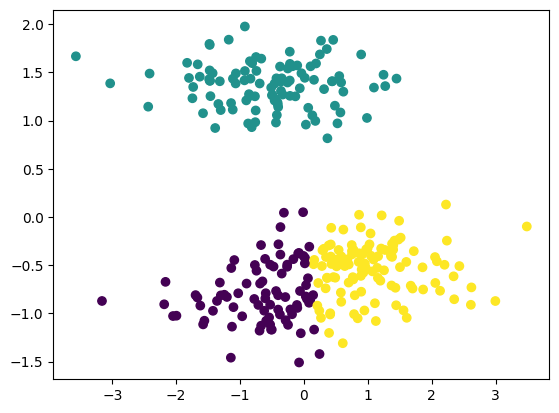

In [45]:
plt.scatter(x_test[:,0], x_test[:,1], c=y_pred)

In [ ]:
## validate the k value
## kneelocator
## silhouette scoring


In [46]:
## kneelocator
import sys
!{sys.executable} -m pip install kneed

In [47]:
from kneed import KneeLocator

In [48]:
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing') 

In [49]:
kl.elbow

np.int64(3)

In [50]:
# shilhouette scoring

from sklearn.metrics import silhouette_score

In [52]:
silhouette_coefficient = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(x_train)
    score=silhouette_score(x_train, kmeans.labels_)
    silhouette_coefficient.append(score)

In [53]:
silhouette_coefficient

[0.5249443251975074,
 0.49439694818754104,
 0.46324329443326473,
 0.4367602243579854,
 0.402878070439153,
 0.3842148577866908,
 0.3661353098940012,
 0.34788881579425207,
 0.3781035262998931]

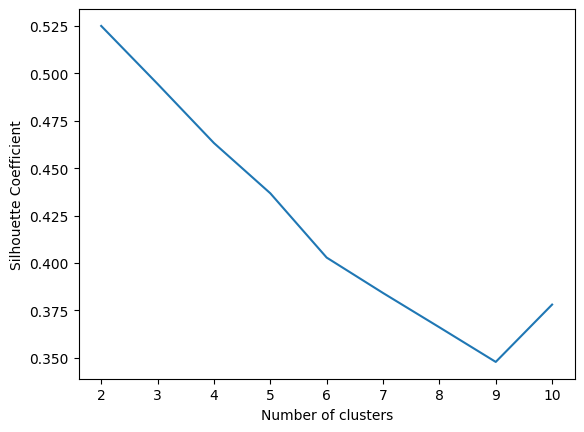

In [54]:
plt.plot(range(2,11), silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()